The following notebook contains EDA for ages 10-13 and 14+.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Get Data from 2020-2024, selecting only relevant features and age groups.

In [22]:
DATA_DIR = Path("/Users/courtneychen/Library/CloudStorage/Box-Box/capstone/data")

dfs = []
for year in range(2020, 2025):
    df = pd.read_parquet(DATA_DIR / f"afcars_{year}.parquet")
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
del dfs
data.head()


,FY,Version,STATE,St,REPDATYR,REPDATMO,FIPSCode,RecNumbr,SEX,AMIAKN,...,Entered,Exited,Served,IsWaiting,IsTPR,AgedOut,RaceEthn,Race,StFCID,year
0,2020,1,37,NC,2020,9,8,R99044225246,2.0,1.0,...,1,0,1,0,0,0,3,3,NCR99044225246,2020
1,2020,1,37,NC,2020,9,8,R99044231032,1.0,0.0,...,0,0,1,0,0,0,1,1,NCR99044231032,2020
2,2020,1,37,NC,2020,9,37051,R99044231063,1.0,0.0,...,0,0,1,0,0,0,99,99,NCR99044231063,2020
3,2020,1,37,NC,2020,9,8,R99044232374,2.0,0.0,...,1,0,1,0,0,0,1,1,NCR99044232374,2020
4,2020,1,37,NC,2020,9,8,R99044238028,1.0,0.0,...,0,0,1,0,0,0,1,1,NCR99044238028,2020


In [23]:
early_teens = data[
    (data["AgeAtStart"] >= 10) &
    (data["AgeAtStart"] <= 13)
]

late_teens = data[
    (data["AgeAtStart"] >= 14) &
    (data["AgeAtStart"] <= 17)
]

adults = data[
    (data["AgeAtStart"] >= 18) &
    (data["AgeAtStart"] <= 21)
]

del data

In [31]:
abuse_cols = ["PHYABUSE", "SEXABUSE", "NEGLECT"]

def plot_abuse_by_year(df, age_group_label):
    # get percent of foster children removed due to each abuse type by year
    summary = (
        df
        .groupby("FY")[abuse_cols]
        .mean()
        .reset_index()
    )

    years = summary["FY"].values
    x = np.arange(len(years))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, col in enumerate(abuse_cols):
        ax.bar(
            x + i * width,
            summary[col] * 100,
            width,
            label=col
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels(years)
    ax.set_ylabel("Children in Foster Care (%)")
    ax.set_xlabel("Fiscal Year")
    ax.set_title(f"Removals due to Maltreatment for Ages {age_group_label}")
    ax.legend(title="Abuse Type")

    plt.tight_layout()
    plt.show()

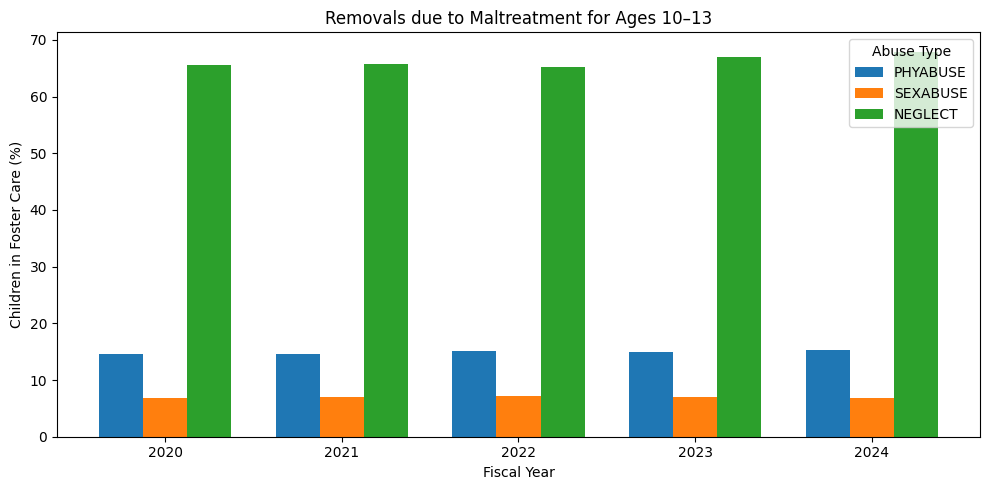

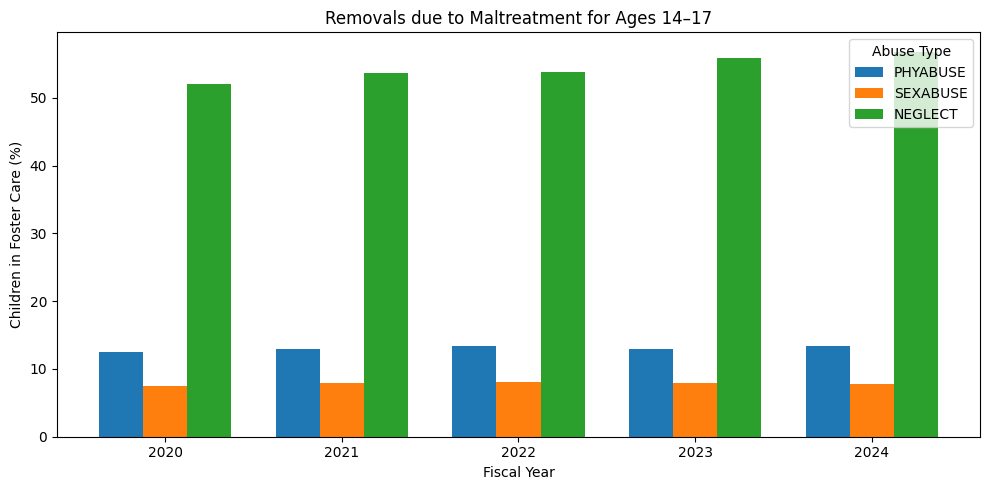

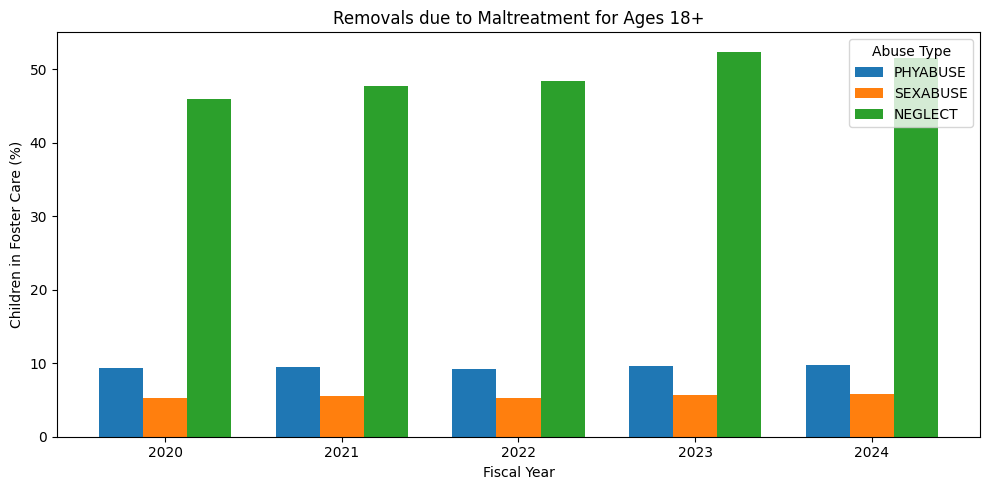

In [32]:
age_groups = [
    (early_teens, "10–13"),
    (late_teens, "14–17"),
    (adults, "18+")
]

for df, label in age_groups:
    plot_abuse_by_year(df, label)
